# Import Libraries

In [14]:
# Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

# Loading CAR Data

In [15]:
# data path (NOTE: CHANGE THIS DEPENDING ON THE PARTICULAR PATH WHERE YOU STORE THE CAR DATA)
data_path = "/Users/willkrew/Desktop/Classes/STAT_390/Data/"

folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [16]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [17]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

# Checking the datatype of all the columns
df_main.dtypes


# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

# Filtering data for relevant rows / time difference columns

In [18]:
# --- 1) FILTER ROWS ---------------------------------------------------------

# Define the three conditions

# Rows that represent a particular menu
cond1 = (
    df_main['EP Name'].notna() &
    df_main['Flow Name'].isna() &
    df_main['Activity Name'].isna()
)

# Rows that represent the beginning / end of a call journey
cond2 = (
    df_main['EP Name'].notna() &
    df_main['Activity Name'].notna() &
    df_main['Flow Name'].isna()
)

# rows that represent presence within a queue
cond3 = df_main['Queue Name'].notna()

# Keep rows that satisfy ANY of the three conditions
df_filt = df_main[cond1 | cond2 | cond3].copy()

# --- 2) TIME DELTA (seconds since previous menu and seconds to next menu within each Contact Session ID) ---

# Sort so "previous row" is truly the prior event in time for that session
# df_filt = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# a) Compute per-session time difference (first row per session will be NaN)
df_filt['seconds_since_prev'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .diff()
           .dt.total_seconds()
)
# b) seconds until next row (last row per session -> NaN)
df_filt['seconds_until_next'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .shift(-1)
           .sub(df_filt['Activity Start Timestamp'])
           .dt.total_seconds()
)

# df_filt now has the filtered rows plus the new 'seconds_since_prev' column


# Defining new columns

- Reached_queue: caller reaches a queue
- Reached_dead_end: caller reaches a dead end (i.e. a submenu / prompt that refers them to a non Legal aid source)
- Call_successful: caller reaches some desired destination (either a queue or dead end)
- Num_visits: number of times a caller visits a particular menu (in this case LegalMenu2)
- After_first_LegalMenu2_activity: The menu (if any) visited directly after the first visit to LegalMenu2
- After_second_LegalMenu2_activity: The menu (if any) visited directly after the second visit to LegalMenu2
- After_final_LegalMenu2_activity: The menu (if any) visited directly after the final visit to LegalMenu2
- First_LegalMenu2_seconds_until_next: The time (seconds) spent during the first visit to LegalMenu2

In [19]:
g = df_filt.groupby('Contact Session ID')

# 1) REACHED QUEUE (old Call_successful logic)
queue_hit = df_filt['Activity Name'].astype(str).str.contains('queue', case=False, na=False)
queue_present = df_filt['Queue Name'].notna()

df_filt['Reached_queue'] = (
    (queue_hit | queue_present)
      .groupby(df_filt['Contact Session ID'])
      .transform('any')
      .astype(int)
)

# 2) REACHED DEAD-END MENUS (corrected names)
dead_end_names = {
    'ChildSupportMenu',
    'WorkersCompMenu',
    'ImmigrationOtherMenu',
    'OtherLegalCriminalCaseMenu',
    'OtherLegalPersonalInjuryMenu',
    'OtherLegalOtherMenu',
    'TenantDeterrenceMenu'
}

dead_end_mask = df_filt['Activity Name'].isin(dead_end_names)

df_filt['Reached_dead_end'] = (
    dead_end_mask
      .groupby(df_filt['Contact Session ID'])
      .transform('any')
      .astype(int)
)

# 3) NEW Call_successful = Reached_queue OR Reached_dead_end
df_filt['Call_successful'] = (
    (df_filt['Reached_queue'].eq(1) | df_filt['Reached_dead_end'].eq(1))
    .astype(int)
)

# 4) Num_visits: count of rows with Activity Name exactly 'LegalMenu2'
legal_mask = df_filt['Activity Name'].eq('LegalMenu2')
df_filt['Num_visits'] = (
    legal_mask.groupby(df_filt['Contact Session ID'])
              .transform('sum')
)

# 5) Helper: next Activity Name within session (row-wise shift)
df_filt['_next_activity_in_session'] = g['Activity Name'].shift(-1)

# 6) FIRST LegalMenu2 row per session
cum_legal = legal_mask.groupby(df_filt['Contact Session ID']).cumsum()
first_legal_mask = legal_mask & (cum_legal == 1)

first_legal_next_activity_by_session = (
    df_filt.loc[first_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
          .drop_duplicates('Contact Session ID')
          .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_first_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(first_legal_next_activity_by_session)

first_legal_wait_by_session = (
    df_filt.loc[first_legal_mask, ['Contact Session ID', 'seconds_until_next']]
          .drop_duplicates('Contact Session ID')
          .set_index('Contact Session ID')['seconds_until_next']
)
df_filt['First_LegalMenu2_seconds_until_next'] = df_filt['Contact Session ID'].map(first_legal_wait_by_session)

# 7) SECOND and FINAL LegalMenu2 logic
legal_ord = legal_mask.groupby(df_filt['Contact Session ID']).cumsum()
legal_total = legal_mask.groupby(df_filt['Contact Session ID']).transform('sum')

second_legal_mask = legal_mask & (legal_ord == 2)
final_legal_mask  = legal_mask & (legal_ord == legal_total) & (legal_total > 0)

second_next_by_session = (
    df_filt.loc[second_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
      .drop_duplicates('Contact Session ID')
      .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_second_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(second_next_by_session)

final_next_by_session = (
    df_filt.loc[final_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
      .drop_duplicates('Contact Session ID')
      .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_final_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(final_next_by_session)

# 8) clean helper
df_filt.drop(columns=['_next_activity_in_session'], inplace=True)


### Filtering For All Callers Entering TransferToSafeHaven Chatbot

In [20]:
# Exact match in 'Activity Name'
chatbot_ids = (
    df_filt.loc[df_filt['Activity Name'] == 'TransferToSafeHaven', 'Contact Session ID']
          .dropna()
          .unique()
          .tolist()
)

df_chatbot = df_filt[df_filt['Contact Session ID'].isin(chatbot_ids)].copy()

# order IDs by first appearance
id_order = df_chatbot['Contact Session ID'].drop_duplicates()
cs_cat = pd.Categorical(df_chatbot['Contact Session ID'],
                        categories=id_order, ordered=True)

df_chatbot = df_chatbot.assign(_cs_cat=cs_cat).sort_values(
    ['_cs_cat', 'Activity Start Timestamp'],
    kind='stable'  # preserves original order when timestamps tie
).drop(columns=['_cs_cat'])


### Filtering For All Callers That Entered FamilyMenu From Aug 11 - 29 2025 (chatbot period)

In [21]:
df_aug11_29 = df_filt[df_filt['Activity Start Timestamp']
                      .between('2025-08-11', '2025-08-29 23:59:59.999999999', inclusive='both')].copy()

familymenu_ids_aug11_29 = (
    df_aug11_29.loc[df_aug11_29['Activity Name'] == 'FamilyMenu', 'Contact Session ID']
          .dropna()
          .unique()
          .tolist()
)

df_aug11_29_familymenu = df_aug11_29[df_aug11_29['Contact Session ID'].isin(familymenu_ids_aug11_29)].copy()

# order IDs by first appearance
id_order = df_aug11_29_familymenu['Contact Session ID'].drop_duplicates()
cs_cat = pd.Categorical(df_aug11_29_familymenu['Contact Session ID'],
                        categories=id_order, ordered=True)

df_aug11_29_familymenu = df_aug11_29_familymenu.assign(_cs_cat=cs_cat).sort_values(
    ['_cs_cat', 'Activity Start Timestamp'],
    kind='stable'  # preserves original order when timestamps tie
).drop(columns=['_cs_cat'])

### Filtering For All Callers That Entered FamilyMenu OUTSIDE OF Aug 11 - 29 2025

In [29]:
familymenu_ids = (
    df_filt.loc[df_filt['Activity Name'] == 'FamilyMenu', 'Contact Session ID']
          .dropna()
          .unique()
          .tolist()
)

df_filt_familymenu = df_filt[df_filt['Contact Session ID'].isin(familymenu_ids)].copy()

# order IDs by first appearance
id_order = df_filt_familymenu['Contact Session ID'].drop_duplicates()
cs_cat = pd.Categorical(df_filt_familymenu['Contact Session ID'],
                        categories=id_order, ordered=True)

df_filt_familymenu = df_filt_familymenu.assign(_cs_cat=cs_cat).sort_values(
    ['_cs_cat', 'Activity Start Timestamp'],
    kind='stable'  # preserves original order when timestamps tie
).drop(columns=['_cs_cat'])

df_filt_familymenu_no_aug11_29 = df_filt_familymenu[~df_filt_familymenu['Activity Start Timestamp']
                      .between('2025-08-11', '2025-08-29 23:59:59.999999999', inclusive='both')].copy()


# Count / redundancy rate (% callers with mutiple legalmenu visits) / success rate of FamilyMenu Callers during and outside Aug 11 - 29 by whether they pressed option 2 in FamilyMenu (chatbot replaced the DivorceOrParentingMenu)

In [90]:
# ---------------------------
# 0) Helpers & normalization
# ---------------------------

def activity_to_key(activity: object) -> str:
    """Map Activity Name to LegalMenu key; Unknown if not matched."""
    if pd.isna(activity): return 'Abandon'
    s = str(activity).strip().lower()
    if s == 'hivmenu': return '1'
    if s == 'familymenu': return '2'
    if s == 'housingmenu': return '3'
    if s == 'benefitsmenu': return '4'
    if s in ('getloggedinconsumeragents', 'getloggedinconsumerspagents'): return '5'
    if s == 'criminalrecordsvoicemailtransfer': return '6'
    if s == 'employmentmenu': return '7'
    if s == 'immigrationmenu': return '8'
    if s in ('getloggedinadaptagents', 'getloggedinadaptspagents'): return '9'
    if s == 'otherlegalmenu': return '10'
    if s == 'legalmenu2': return '#'
    if s in ('frontdesktransfer', 'holidayprompt'): return '*'
    return 'Unknown'

def add_session_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build one row per Contact Session ID, lifting EXISTING session-level columns
    exactly the same way you already do for Num_visits / After_* / t_first_choice:
    via drop_duplicates on Contact Session ID.

    If a flag (e.g., Reached_chatbot) does not exist in df, we optionally derive it;
    otherwise we use the provided column as-is.
    """
    df = df.copy()

    # Always-lifted session columns (like you already do)
    base_cols = [
        'Contact Session ID',
        'Num_visits',
        'After_first_LegalMenu2_activity',
        'After_final_LegalMenu2_activity',
        'First_LegalMenu2_seconds_until_next',
    ]

    # Flags we will lift *if present* (no recomputation)
    flag_cols = [
        'Reached_queue',          # provided in your df
        'Reached_dead_end',       # provided in your df
        'Call_successful',        # provided in your df
        'Reached_chatbot',        # may exist in Aug 11–29 data; if not, we’ll derive below
    ]

    # Keep only columns that actually exist
    take_cols = [c for c in base_cols + flag_cols if c in df.columns]

    sess = (
        df[take_cols]
        .drop_duplicates('Contact Session ID')
        .rename(columns={'First_LegalMenu2_seconds_until_next': 't_first_choice'})
        .copy()
    )

    # Map keys from activities (same as before)
    sess['After_first_key'] = sess['After_first_LegalMenu2_activity'].map(activity_to_key)
    sess['After_final_key'] = sess['After_final_LegalMenu2_activity'].map(activity_to_key)

    # If Reached_chatbot not provided, derive it (ONLY this one; others are taken as-is)
    if 'Reached_chatbot' not in sess.columns:
        reached_chatbot = (
            df.assign(_act=df['Activity Name'].astype(str))
              .groupby('Contact Session ID', sort=False)['_act']
              .apply(lambda s: (s == 'TransferToSafeHaven').any())
              .astype(int)
              .rename('Reached_chatbot')
        )
        sess = sess.merge(reached_chatbot, left_on='Contact Session ID', right_index=True, how='left')
    else:
        # ensure int dtype if it exists
        sess['Reached_chatbot'] = sess['Reached_chatbot'].fillna(0).astype(int)

    # Derive DP_path (visited DivorceOrParentingMenu) – not provided in your df
    dp_path = (
        df.assign(_act=df['Activity Name'].astype(str))
          .groupby('Contact Session ID', sort=False)['_act']
          .apply(lambda s: (s == 'DivorceOrParentingMenu').any())
          .astype(int)
          .rename('DP_path')
    )
    sess = sess.merge(dp_path, left_on='Contact Session ID', right_index=True, how='left')

    # Compute “success w/o chatbot” from lifted flags (do NOT recompute flags themselves)
    if 'Reached_queue' in sess.columns and 'Reached_dead_end' in sess.columns:
        sess['Call_successful_no_chatbot'] = ((sess['Reached_queue'] == 1) | (sess['Reached_dead_end'] == 1)).astype(int)
    else:
        # if either flag is missing, create a placeholder
        sess['Call_successful_no_chatbot'] = 0

    # Confusion proxies from t_first_choice (same style as before)
    sess['mem_1s'] = (sess['t_first_choice'] <= 1.0).astype(float)
    sess['mem_9s'] = (sess['t_first_choice'] <= 9.0).astype(float)

    # Normalize any missing lifted flags to 0 (only for columns that made it in)
    for c in ['Reached_queue', 'Reached_dead_end', 'Call_successful',
              'Reached_chatbot', 'Call_successful_no_chatbot', 'DP_path', 'mem_1s', 'mem_9s']:
        if c in sess.columns:
            sess[c] = sess[c].fillna(0)

    return sess



def summarize_session_table(sess: pd.DataFrame, label: str) -> dict:
    """Return a dict of DataFrames with key metrics for this period."""
    out = {}
    N = len(sess)

    out['meta'] = pd.DataFrame({'Period':[label], 'Sessions':[N]})

    # Redundancy
    red = (sess['Num_visits'] > 1).value_counts().reindex([False, True], fill_value=0)
    out['redundancy'] = pd.DataFrame({
        'Period': label,
        'Num_visits==1': int(red.get(False,0)),
        'Num_visits>1' : int(red.get(True,0)),
        'Pct_repeat'   : round(100 * red.get(True,0) / N, 1) if N else 0.0
    }, index=[0])

    # Outcomes (keeping chatbot separate)
    dest_counts = pd.DataFrame({
        'Reached_queue'             : [int(sess['Reached_queue'].sum())],
        'Reached_dead_end'          : [int(sess['Reached_dead_end'].sum())],
        'Reached_chatbot'           : [int(sess['Reached_chatbot'].sum())],
        'Call_successful_no_chatbot': [int(sess['Call_successful_no_chatbot'].sum())],
    })
    dest_pcts = dest_counts.divide(N).mul(100).round(1) if N else dest_counts*0
    out['destinations_counts'] = pd.concat([pd.DataFrame({'Period':[label], 'N':[N]}), dest_counts], axis=1)
    out['destinations_pcts']   = pd.concat([pd.DataFrame({'Period':[label], 'N':[N]}), dest_pcts], axis=1)

    # First / Final submenu distributions
    def dist(series):
        vc = series.fillna('NaN').value_counts().sort_index()
        return vc.rename_axis('Value').to_frame('Count').assign(Percent=lambda d: (d['Count']/N*100).round(1) if N else 0)

    out['after_first_key_dist']  = dist(sess['After_first_key'])
    out['after_final_key_dist']  = dist(sess['After_final_key'])
    out['after_first_act_dist']  = dist(sess['After_first_LegalMenu2_activity'])
    out['after_final_act_dist']  = dist(sess['After_final_LegalMenu2_activity'])

    # Multi-visit slice
    mv = sess[sess['Num_visits'] > 1]
    Nm = len(mv)
    def dist_mv(series):
        vc = series.fillna('NaN').value_counts().sort_index()
        return vc.rename_axis('Value').to_frame('Count').assign(Percent=lambda d: (d['Count']/Nm*100).round(1) if Nm else 0)

    out['MV_after_first_key_dist'] = dist_mv(mv['After_first_key'])
    out['MV_after_final_key_dist'] = dist_mv(mv['After_final_key'])

    # Confusion proxies
    out['confusion'] = pd.DataFrame({
        'Period':[label],
        'N_with_time'       : [int(sess['t_first_choice'].notna().sum())],
        'Median_t_first_sec': [float(sess['t_first_choice'].median()) if sess['t_first_choice'].notna().any() else np.nan],
        'Pct_<=1s'          : [round(100 * sess['mem_1s'].mean(),1) if N else 0.0],
        'Pct_<=9s'          : [round(100 * sess['mem_9s'].mean(),1) if N else 0.0],
    })

    return out

def pretty_print(title, df):
    print(f"\n=== {title} ===")
    display(df)


# ---------------------------------------------------
# Build session-level tables for both periods
# ---------------------------------------------------

sess_no_bot  = add_session_flags(df_filt_familymenu_no_aug11_29)  # Pre/Post (exclude Aug 11–29)
sess_aug_all = add_session_flags(df_aug11_29_familymenu)          # Aug 11–29 (mixed)

# ---------------------------------------------------
# Cohort splits
#  - Definition of "Option 2": visited DP_menu (DP_path==1) OR entered chatbot
#  - Pre/Post has NO chatbot cohort; just Option 2 (ANY) vs Not Option 2
#  - Aug 11–29: include ALL + Option 2 (ANY), Option 2 & Chatbot, Option 2 & No Chatbot, Not Option 2
# ---------------------------------------------------

# ---- Pre/Post (exclude Aug 11–29) ----
pre_opt2_any_mask  = (sess_no_bot['DP_path'] == 1) | (sess_no_bot['Reached_chatbot'] == 1)  # chatbot will be 0 here
pre_not_opt2_mask  = (sess_no_bot['DP_path'] == 0) & (sess_no_bot['Reached_chatbot'] == 0)

sess_pre_opt2_any  = sess_no_bot[pre_opt2_any_mask].copy()
sess_pre_not_opt2  = sess_no_bot[pre_not_opt2_mask].copy()

# ---- Aug 11–29 ----
aug_opt2_any_mask    = (sess_aug_all['DP_path'] == 1) | (sess_aug_all['Reached_chatbot'] == 1)
aug_opt2_chat_mask   = aug_opt2_any_mask & (sess_aug_all['Reached_chatbot'] == 1)
aug_opt2_nochat_mask = aug_opt2_any_mask & (sess_aug_all['Reached_chatbot'] == 0)
aug_not_opt2_mask    = (sess_aug_all['DP_path'] == 0) & (sess_aug_all['Reached_chatbot'] == 0)

sess_aug_opt2_any    = sess_aug_all[aug_opt2_any_mask].copy()
sess_aug_opt2_chat   = sess_aug_all[aug_opt2_chat_mask].copy()
sess_aug_opt2_nochat = sess_aug_all[aug_opt2_nochat_mask].copy()
sess_aug_not_opt2    = sess_aug_all[aug_not_opt2_mask].copy()

# ---------------------------------------------------
# Summaries
# ---------------------------------------------------

# Pre/Post cohorts
summary_pre_all        = summarize_session_table(sess_no_bot,           label='Pre/Post — ALL')
summary_pre_opt2_any   = summarize_session_table(sess_pre_opt2_any,     label='Pre/Post — Option 2')
summary_pre_not_opt2   = summarize_session_table(sess_pre_not_opt2,     label='Pre/Post — Not Option 2')

# Aug cohorts (including ALL)
summary_aug_all          = summarize_session_table(sess_aug_all,          label='Aug 11–29 — ALL')
summary_aug_opt2_any     = summarize_session_table(sess_aug_opt2_any,     label='Aug 11–29 — Option 2 (ANY)')
summary_aug_opt2_chat    = summarize_session_table(sess_aug_opt2_chat,    label='Aug 11–29 — Option 2 & Chatbot')
summary_aug_opt2_nochat  = summarize_session_table(sess_aug_opt2_nochat,  label='Aug 11–29 — Option 2 & No Chatbot')
summary_aug_not_opt2     = summarize_session_table(sess_aug_not_opt2,     label='Aug 11–29 — Not Option 2')

# ---------------------------------------------------
# Show key comparisons
# ---------------------------------------------------

# Counts
pretty_print("Counts", pd.concat([
    summary_pre_all['meta'],
    summary_pre_opt2_any['meta'],
    summary_pre_not_opt2['meta'],
    summary_aug_all['meta'],
    summary_aug_opt2_any['meta'],
    summary_aug_opt2_chat['meta'],
    summary_aug_opt2_nochat['meta'],
    summary_aug_not_opt2['meta'],
], ignore_index=True))

# Redundancy
pretty_print("Redundancy (Num_visits > 1)", pd.concat([
    summary_pre_all['redundancy'],
    summary_pre_opt2_any['redundancy'],
    summary_pre_not_opt2['redundancy'],
    summary_aug_all['redundancy'],
    summary_aug_opt2_any['redundancy'],
    summary_aug_opt2_chat['redundancy'],
    summary_aug_opt2_nochat['redundancy'],
    summary_aug_not_opt2['redundancy'],
], ignore_index=True))

# Destinations — counts
pretty_print("Destinations — counts", pd.concat([
    summary_pre_all['destinations_counts'],
    summary_pre_opt2_any['destinations_counts'],
    summary_pre_not_opt2['destinations_counts'],
    summary_aug_all['destinations_counts'],
    summary_aug_opt2_any['destinations_counts'],
    summary_aug_opt2_chat['destinations_counts'],
    summary_aug_opt2_nochat['destinations_counts'],
    summary_aug_not_opt2['destinations_counts'],
], ignore_index=True))

# Destinations — percents
pretty_print("Destinations — percents", pd.concat([
    summary_pre_all['destinations_pcts'],
    summary_pre_opt2_any['destinations_pcts'],
    summary_pre_not_opt2['destinations_pcts'],
    summary_aug_all['destinations_pcts'],
    summary_aug_opt2_any['destinations_pcts'],
    summary_aug_opt2_chat['destinations_pcts'],
    summary_aug_opt2_nochat['destinations_pcts'],
    summary_aug_not_opt2['destinations_pcts'],
], ignore_index=True))

# Confusion proxies
pretty_print("Confusion proxies (time at first LegalMenu2)", pd.concat([
    summary_pre_all['confusion'],
    summary_pre_opt2_any['confusion'],
    summary_pre_not_opt2['confusion'],
    summary_aug_all['confusion'],
    summary_aug_opt2_any['confusion'],
    summary_aug_opt2_chat['confusion'],
    summary_aug_opt2_nochat['confusion'],
    summary_aug_not_opt2['confusion'],
], ignore_index=True))

# Multi-visit: After FIRST key distribution — by cohort
pretty_print("Multi-visit: After FIRST key distribution — by cohort", pd.concat([
    summary_pre_all['MV_after_first_key_dist'].assign(Period='Pre/Post — ALL').reset_index(),
    summary_pre_opt2_any['MV_after_first_key_dist'].assign(Period='Pre/Post — Option 2').reset_index(),
    summary_pre_not_opt2['MV_after_first_key_dist'].assign(Period='Pre/Post — Not Option 2').reset_index(),
    summary_aug_all['MV_after_first_key_dist'].assign(Period='Aug 11–29 — ALL').reset_index(),
    summary_aug_opt2_any['MV_after_first_key_dist'].assign(Period='Aug 11–29 — Option 2 (ANY)').reset_index(),
    summary_aug_opt2_chat['MV_after_first_key_dist'].assign(Period='Aug 11–29 — Option 2 & Chatbot').reset_index(),
    summary_aug_opt2_nochat['MV_after_first_key_dist'].assign(Period='Aug 11–29 — Option 2 & No Chatbot').reset_index(),
    summary_aug_not_opt2['MV_after_first_key_dist'].assign(Period='Aug 11–29 — Not Option 2').reset_index(),
], ignore_index=True))

# Multi-visit: After FINAL key distribution — by cohort
pretty_print("Multi-visit: After FINAL key distribution — by cohort", pd.concat([
    summary_pre_all['MV_after_final_key_dist'].assign(Period='Pre/Post — ALL').reset_index(),
    summary_pre_opt2_any['MV_after_final_key_dist'].assign(Period='Pre/Post — Option 2').reset_index(),
    summary_pre_not_opt2['MV_after_final_key_dist'].assign(Period='Pre/Post — Not Option 2').reset_index(),
    summary_aug_all['MV_after_final_key_dist'].assign(Period='Aug 11–29 — ALL').reset_index(),
    summary_aug_opt2_any['MV_after_final_key_dist'].assign(Period='Aug 11–29 — Option 2 (ANY)').reset_index(),
    summary_aug_opt2_chat['MV_after_final_key_dist'].assign(Period='Aug 11–29 — Option 2 & Chatbot').reset_index(),
    summary_aug_opt2_nochat['MV_after_final_key_dist'].assign(Period='Aug 11–29 — Option 2 & No Chatbot').reset_index(),
    summary_aug_not_opt2['MV_after_final_key_dist'].assign(Period='Aug 11–29 — Not Option 2').reset_index(),
], ignore_index=True))


=== Counts ===


,Period,Sessions
0,Pre/Post — ALL,23729
1,Pre/Post — Option 2,11454
2,Pre/Post — Not Option 2,12275
3,Aug 11–29 — ALL,1065
4,Aug 11–29 — Option 2 (ANY),536
5,Aug 11–29 — Option 2 & Chatbot,412
6,Aug 11–29 — Option 2 & No Chatbot,124
7,Aug 11–29 — Not Option 2,529



=== Redundancy (Num_visits > 1) ===


,Period,Num_visits==1,Num_visits>1,Pct_repeat
0,Pre/Post — ALL,19700,4029,17.0
1,Pre/Post — Option 2,10181,1273,11.1
2,Pre/Post — Not Option 2,9519,2756,22.5
3,Aug 11–29 — ALL,891,174,16.3
4,Aug 11–29 — Option 2 (ANY),466,70,13.1
5,Aug 11–29 — Option 2 & Chatbot,358,54,13.1
6,Aug 11–29 — Option 2 & No Chatbot,108,16,12.9
7,Aug 11–29 — Not Option 2,425,104,19.7



=== Destinations — counts ===


...

,Period,N_with_time,Median_t_first_sec,Pct_<=1s,Pct_<=9s
0,Pre/Post — ALL,23729,36.0,0.1,2.6
1,Pre/Post — Option 2,11454,36.0,0.0,1.8
2,Pre/Post — Not Option 2,12275,36.0,0.1,3.3
3,Aug 11–29 — ALL,1065,36.0,0.4,3.0
4,Aug 11–29 — Option 2 (ANY),536,36.0,0.2,2.4
5,Aug 11–29 — Option 2 & Chatbot,412,35.0,0.2,2.2
6,Aug 11–29 — Option 2 & No Chatbot,124,38.0,0.0,3.2
7,Aug 11–29 — Not Option 2,529,36.0,0.6,3.6



=== Multi-visit: After FIRST key distribution — by cohort ===


,Value,Count,Percent,Period
0,#,1167,29.0,Pre/Post — ALL
1,1,140,3.5,Pre/Post — ALL
2,10,323,8.0,Pre/Post — ALL
3,2,2103,52.2,Pre/Post — ALL
4,3,244,6.1,Pre/Post — ALL
5,4,31,0.8,Pre/Post — ALL
6,7,13,0.3,Pre/Post — ALL
7,8,8,0.2,Pre/Post — ALL
8,#,547,43.0,Pre/Post — Option 2
9,1,43,3.4,Pre/Post — Option 2



=== Multi-visit: After FINAL key distribution — by cohort ===


,Value,Count,Percent,Period
0,*,19,0.5,Pre/Post — ALL
1,1,49,1.2,Pre/Post — ALL
2,10,319,7.9,Pre/Post — ALL
3,2,2187,54.3,Pre/Post — ALL
4,3,181,4.5,Pre/Post — ALL
5,4,91,2.3,Pre/Post — ALL
6,5,9,0.2,Pre/Post — ALL
7,6,30,0.7,Pre/Post — ALL
8,7,19,0.5,Pre/Post — ALL
9,8,19,0.5,Pre/Post — ALL


# Visualization of submenus chosen after first and final visit to legalmenu for callers that visited FamilyMenu and also visited legal menu multiple times (separated by whether they chose option 2 during their call journey)

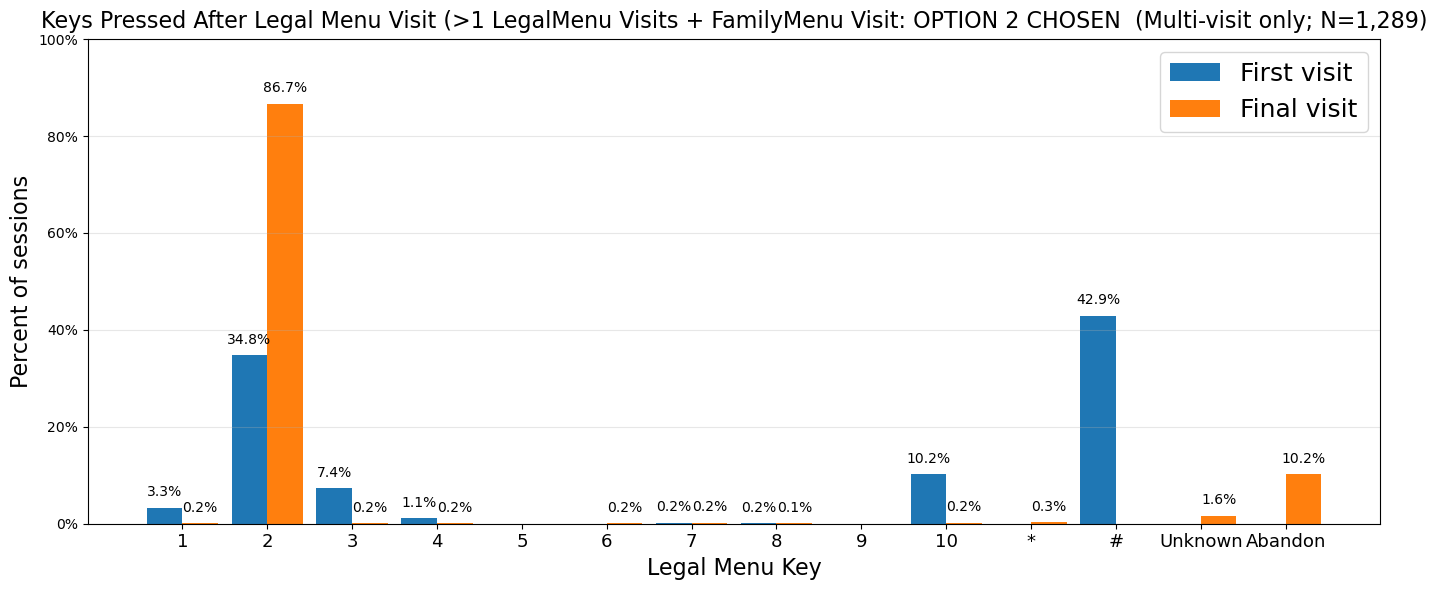

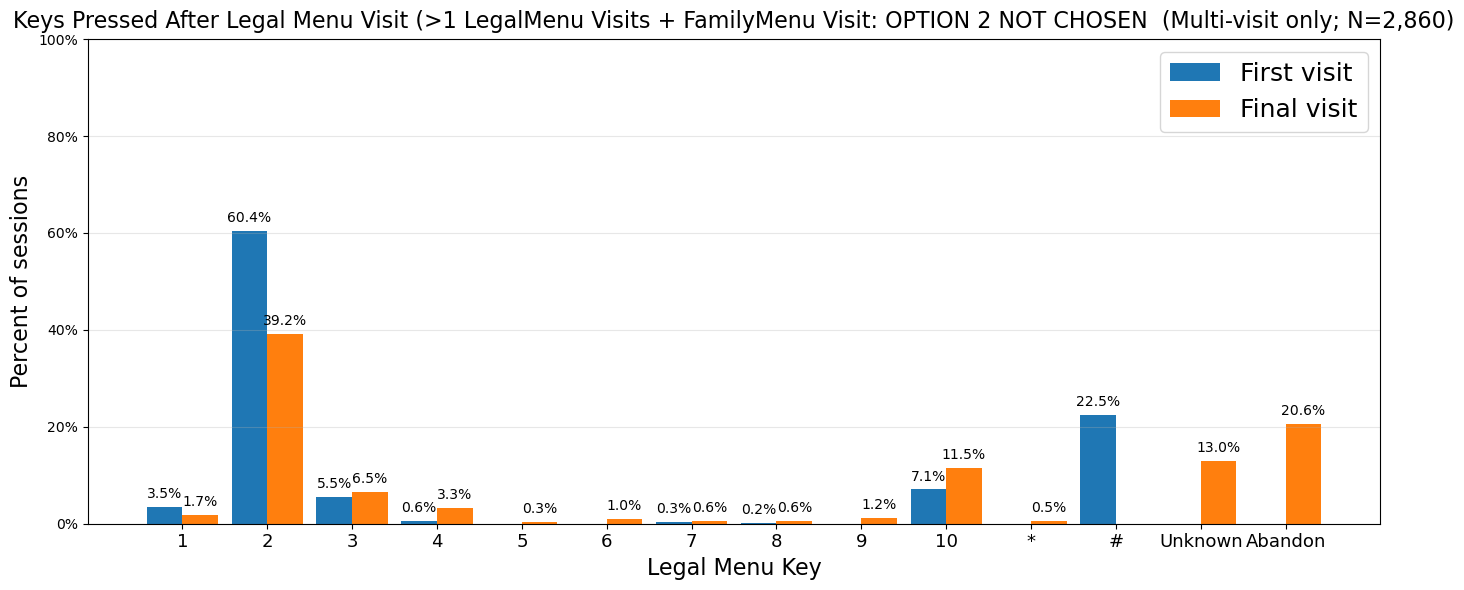

In [103]:

# --- Combine cohorts (re-uses session tables you already built earlier) ---
# Option 2 = visited DP menu OR (during Aug 11–29) entered chatbot.
# For Aug, we only include the "Option 2 & No Chatbot" part here per your earlier spec.

cohort_opt2 = pd.concat(
    [sess_pre_opt2_any,     # Pre/Post — Option 2
     sess_aug_opt2_nochat], # Aug 11–29 — Option 2 & No Chatbot
    ignore_index=True
)

cohort_not2 = pd.concat(
    [sess_pre_not_opt2,     # Pre/Post — Not Option 2
     sess_aug_not_opt2],    # Aug 11–29 — Not Option 2
    ignore_index=True
)

# --- Helper: make a grouped bar chart of First vs Final key % for multi-visit sessions ---
def plot_first_final_keys(cohort_sess: pd.DataFrame, title: str, key_order=None):
    """
    Shows, among Num_visits > 1, the distribution (percent) across keys for:
      - After_first_key
      - After_final_key
    Side-by-side bars per key, with a legend ("First visit", "Final visit").
    """
    mv = cohort_sess[cohort_sess['Num_visits'] > 1].copy()
    Nm = len(mv)

    if key_order is None:
        key_order = ['1','2','3','4','5','6','7','8','9','10','*','#','Unknown','Abandon']

    # Percent distributions
    first_counts = mv['After_first_key'].value_counts().reindex(key_order, fill_value=0)
    final_counts = mv['After_final_key'].value_counts().reindex(key_order, fill_value=0)

    first_pct = (first_counts / Nm * 100) if Nm else first_counts*0
    final_pct = (final_counts / Nm * 100) if Nm else final_counts*0

    # Plot
    x = np.arange(len(key_order))
    width = 0.42

    fig, ax = plt.subplots(figsize=(14, 6))
    b1 = ax.bar(x - width/2, first_pct.values, width, label='First visit')
    b2 = ax.bar(x + width/2, final_pct.values, width, label='Final visit')

    ax.set_title(f"{title}  (Multi-visit only; N={Nm:,})", fontsize=16, pad=8)
    ax.set_xlabel("Legal Menu Key", fontsize=16)
    ax.set_ylabel("Percent of sessions", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(key_order, fontsize=13)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.grid(axis='y', alpha=0.3, linewidth=0.8)
    ax.legend(fontsize = 18)

    # Labels above bars
    ymax = max(first_pct.max(), final_pct.max()) if Nm else 0
    ax.set_ylim(0, max(100, ymax*1.15))
    for rects, vals in [(b1, first_pct.values), (b2, final_pct.values)]:
        for r, v in zip(rects, vals):
            if v > 0:
                ax.text(r.get_x() + r.get_width()/2,
                        r.get_height() + max(0.5, 0.02*ymax),
                        f"{v:.1f}%",
                        ha='center', va='bottom', fontsize=10, color='black')

    plt.tight_layout()
    plt.show()

# --- Make the two requested plots ---
plot_first_final_keys(cohort_opt2, title="Keys Pressed After Legal Menu Visit (>1 LegalMenu Visits + FamilyMenu Visit: OPTION 2 CHOSEN")
plot_first_final_keys(cohort_not2, title="Keys Pressed After Legal Menu Visit (>1 LegalMenu Visits + FamilyMenu Visit: OPTION 2 NOT CHOSEN")
